# Assignment 1 - Exploratory Data Analysis (EDA)

## Snitch Fashion Sales Dataset

### Objective
The purpose of this notebook is to perform a complete **Exploratory Data Analysis (EDA)** on the selected dataset, including:
- data inspection
- data cleaning
- visualization
- insights and interpretation

This notebook follows the assignment requirements by including:
- explanation of cleaning steps
- reasons why cleaning was needed
- before and after cleaning views
- 8 clear visualizations
- insights from the results


## 1. Import libraries and load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("Snitch_Fashion_Sales_Uncleaned.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/Assignment1/Snitch_Fashion_Sales_Uncleaned.csv")

df = pd.read_csv(DATA_PATH)
print("Dataset loaded from:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


Dataset loaded from: Snitch_Fashion_Sales_Uncleaned.csv
Shape: (2500, 12)


,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66


## 2. Basic information about the dataset

In [2]:
print("Number of rows and columns:", df.shape)
print("\nColumn names:")
print(list(df.columns))
print("\nData types:")
print(df.dtypes)

Number of rows and columns: (2500, 12)

Column names:
['Order_ID', 'Customer_Name', 'Product_Category', 'Product_Name', 'Units_Sold', 'Unit_Price', 'Discount_%', 'Sales_Amount', 'Order_Date', 'City', 'Segment', 'Profit']

Data types:
Order_ID              int64
Customer_Name        object
Product_Category     object
Product_Name         object
Units_Sold          float64
Unit_Price          float64
Discount_%          float64
Sales_Amount        float64
Order_Date           object
City                 object
Segment              object
Profit              float64
dtype: object


## 3. Before cleaning - dataset preview

The following output shows a sample of the raw dataset **before cleaning**.  
This can be used as the **before cleaning screenshot** required in the assignment.


In [3]:
df.head(10)

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66
5,1005,Samuel Miller,T-Shirts,Crop Top,NaN,NaN,NaN,0.00,2023-12-05,Mumbai,B2B,1477.73
6,1006,John Mclean,Jeans,Boyfriend Jeans,1.0,2060.85,NaN,0.00,2024-04-02,Ahmedabad,B2B,198.36
7,1007,Dr. Kathryn Bass PhD,Dresses,Casual Midi,NaN,3669.56,NaN,0.00,NaN,Bangalore,B2C,2490.01
8,1008,Marie Fisher,Accessories,Sunglasses,NaN,NaN,NaN,0.00,NaN,Ahmedabad,B2C,-886.80
9,1009,Dale Perry,T-Shirts,Oversized T-shirt,5.0,NaN,NaN,0.00,2025-07-20,Bangalore,B2B,-972.73


## 4. Before cleaning - data quality issues

Cleaning was needed because the dataset contains:
- missing values
- duplicate `Order_ID` values
- inconsistent city names
- mixed date formats
- invalid numeric values
- suspicious sales values

The tables below show the problems before cleaning.


In [4]:
missing_before = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)

missing_before

,Missing Values,Missing %
Discount_%,1651,66.04
Units_Sold,1306,52.24
Unit_Price,1210,48.40
Segment,821,32.84
Order_Date,606,24.24
Product_Category,0,0.00
Customer_Name,0,0.00
Order_ID,0,0.00
Product_Name,0,0.00
Sales_Amount,0,0.00


In [5]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate Order_ID values:", df["Order_ID"].duplicated().sum())
print("Non-positive Units_Sold values:", ((df["Units_Sold"] <= 0).fillna(False)).sum())
print("Invalid Discount_% values:", (((df["Discount_%"] < 0) | (df["Discount_%"] > 1)).fillna(False)).sum())
print("Zero Sales_Amount values:", (df["Sales_Amount"] == 0).sum())
print("Negative Sales_Amount values:", (df["Sales_Amount"] < 0).sum())

Exact duplicate rows: 0
Duplicate Order_ID values: 109
Non-positive Units_Sold values: 412
Invalid Discount_% values: 189
Zero Sales_Amount values: 2321
Negative Sales_Amount values: 70


## 5. Explain the data cleaning steps

### Cleaning steps performed
1. **Trim text values** to remove unwanted spaces.
2. **Standardize city names** such as:
   - `Bangalore` → `Bengaluru`
   - `bengaluru` → `Bengaluru`
   - `Hyd` / `hyderbad` → `Hyderabad`
3. **Standardize `Segment`** values to only `B2B` and `B2C`.
4. **Parse mixed date formats** in `Order_Date`.
5. Treat invalid numeric values as missing:
   - `Units_Sold <= 0`
   - `Discount_% < 0 or > 1`
6. Fill missing values using **group-based median imputation**.
7. Recalculate `Sales_Amount` after cleaning.
8. Keep `Profit` as provided, but add a `Profit_Flag` for review.

### Why was cleaning needed?
Cleaning was necessary to ensure that:
- the dataset is consistent
- invalid values do not affect analysis
- visualizations reflect meaningful patterns
- the final analysis is based on a reliable cleaned dataset


In [6]:
cleaned = df.copy()
cleaned.insert(0, "Record_ID", range(1, len(cleaned) + 1))

for col in ["Customer_Name", "Product_Category", "Product_Name", "City", "Segment"]:
    cleaned[col] = cleaned[col].astype("string").str.strip()

city_map = {
    "Bangalore": "Bengaluru",
    "bengaluru": "Bengaluru",
    "Hyd": "Hyderabad",
    "hyderbad": "Hyderabad"
}
cleaned["City"] = cleaned["City"].replace(city_map)

cleaned["Segment"] = cleaned["Segment"].astype("string").str.upper()
cleaned.loc[~cleaned["Segment"].isin(["B2B", "B2C"]), "Segment"] = pd.NA

cleaned["Order_ID_Duplicate_Flag"] = cleaned["Order_ID"].duplicated(keep=False)

dates = pd.to_datetime(cleaned["Order_Date"], errors="coerce", dayfirst=True, format="mixed")

cleaned.loc[cleaned["Units_Sold"] <= 0, "Units_Sold"] = np.nan
cleaned.loc[cleaned["Unit_Price"] <= 0, "Unit_Price"] = np.nan
cleaned.loc[(cleaned["Discount_%"] < 0) | (cleaned["Discount_%"] > 1), "Discount_%"] = np.nan

def fill_group_median(frame, column, groups):
    s = frame[column].copy()
    for g in groups:
        s = s.fillna(frame.groupby(g)[column].transform("median"))
    return s.fillna(frame[column].median())

segment_by_customer = cleaned.groupby("Customer_Name")["Segment"].agg(
    lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty else pd.NA
)
cleaned["Segment"] = cleaned["Segment"].fillna(cleaned["Customer_Name"].map(segment_by_customer))
cleaned["Segment"] = cleaned["Segment"].fillna(cleaned["Segment"].mode(dropna=True).iloc[0])

cleaned["Unit_Price"] = fill_group_median(cleaned, "Unit_Price", ["Product_Name", "Product_Category", "City"])
cleaned["Units_Sold"] = fill_group_median(cleaned, "Units_Sold", ["Product_Name", "Product_Category", "Segment"])
cleaned["Discount_%"] = fill_group_median(cleaned, "Discount_%", ["Product_Category", "Segment"])

cleaned["Units_Sold"] = cleaned["Units_Sold"].round().clip(lower=1).astype(int)
cleaned["Unit_Price"] = cleaned["Unit_Price"].round(2)
cleaned["Discount_%"] = cleaned["Discount_%"].clip(lower=0, upper=1).round(2)

city_median_date = cleaned.assign(_d=dates).groupby("City")["_d"].transform(
    lambda s: s.dropna().sort_values().iloc[len(s.dropna()) // 2] if len(s.dropna()) else pd.NaT
)
dates = dates.fillna(city_median_date)
dates = dates.fillna(dates.dropna().sort_values().iloc[len(dates.dropna()) // 2])

cleaned["Order_Date"] = dates.dt.strftime("%Y-%m-%d")
cleaned["Order_Year"] = dates.dt.year.astype(int)
cleaned["Order_Month"] = dates.dt.month.astype(int)

cleaned["Discount"] = cleaned["Discount_%"]
cleaned["Sales_Amount"] = (cleaned["Units_Sold"] * cleaned["Unit_Price"] * (1 - cleaned["Discount"])).round(2)

cleaned["Profit_Flag"] = np.where(cleaned["Profit"] > cleaned["Sales_Amount"], "Review", "OK")
cleaned.loc[cleaned["Profit"] < 0, "Profit_Flag"] = "Negative"

cleaned = cleaned[[
    "Record_ID", "Order_ID", "Order_ID_Duplicate_Flag", "Customer_Name",
    "Product_Category", "Product_Name", "Units_Sold", "Unit_Price", "Discount",
    "Sales_Amount", "Order_Date", "Order_Year", "Order_Month", "City", "Segment",
    "Profit", "Profit_Flag"
]]

cleaned.head()

,Record_ID,Order_ID,Order_ID_Duplicate_Flag,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount,Sales_Amount,Order_Date,Order_Year,Order_Month,City,Segment,Profit,Profit_Flag
0,1,1000,False,Brian Thompson,Jeans,Slim Fit Jeans,4,842.00,0.60,1347.20,2025-02-27,2025,2,Delhi,B2C,2137.45,Review
1,2,1001,False,Shaun Ross,Jeans,Slim Fit Jeans,1,2366.61,0.44,1325.30,2025-07-15,2025,7,Ahmedabad,B2B,1588.15,Review
2,3,1002,True,Sarah Snyder,Jackets,Puffer Coat,1,637.82,0.54,293.40,2025-01-02,2025,1,Mumbai,B2B,-158.03,Negative
3,4,1003,True,Jay Briggs,Shoes,Loafers,2,2962.27,0.54,2725.29,2025-06-18,2025,6,Bengaluru,B2B,2296.50,OK
4,5,1004,True,Maria Blake,Accessories,Belts,1,2881.07,0.27,2103.18,2024-12-24,2024,12,Hyderabad,B2B,63.66,OK


## 6. After cleaning - dataset preview

The following output shows the cleaned dataset **after cleaning**.  
This can be used as the **after cleaning screenshot** required in the assignment.


In [7]:
cleaned.head(10)

,Record_ID,Order_ID,Order_ID_Duplicate_Flag,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount,Sales_Amount,Order_Date,Order_Year,Order_Month,City,Segment,Profit,Profit_Flag
0,1,1000,False,Brian Thompson,Jeans,Slim Fit Jeans,4,842.00,0.60,1347.20,2025-02-27,2025,2,Delhi,B2C,2137.45,Review
1,2,1001,False,Shaun Ross,Jeans,Slim Fit Jeans,1,2366.61,0.44,1325.30,2025-07-15,2025,7,Ahmedabad,B2B,1588.15,Review
2,3,1002,True,Sarah Snyder,Jackets,Puffer Coat,1,637.82,0.54,293.40,2025-01-02,2025,1,Mumbai,B2B,-158.03,Negative
3,4,1003,True,Jay Briggs,Shoes,Loafers,2,2962.27,0.54,2725.29,2025-06-18,2025,6,Bengaluru,B2B,2296.50,OK
4,5,1004,True,Maria Blake,Accessories,Belts,1,2881.07,0.27,2103.18,2024-12-24,2024,12,Hyderabad,B2B,63.66,OK
5,6,1005,True,Samuel Miller,T-Shirts,Crop Top,4,2001.55,0.50,4003.10,2023-12-05,2023,12,Mumbai,B2B,1477.73,OK
6,7,1006,True,John Mclean,Jeans,Boyfriend Jeans,1,2060.85,0.44,1154.08,2024-04-02,2024,4,Ahmedabad,B2B,198.36,OK
7,8,1007,True,Dr. Kathryn Bass PhD,Dresses,Casual Midi,4,3669.56,0.50,7339.12,2024-11-28,2024,11,Bengaluru,B2C,2490.01,OK
8,9,1008,True,Marie Fisher,Accessories,Sunglasses,3,2577.64,0.51,3789.13,2024-12-19,2024,12,Ahmedabad,B2C,-886.80,Negative
9,10,1009,True,Dale Perry,T-Shirts,Oversized T-shirt,5,3027.66,0.50,7569.15,2025-07-20,2025,7,Bengaluru,B2B,-972.73,Negative


In [8]:
missing_after = pd.DataFrame({
    "Missing Values": cleaned.isna().sum(),
    "Missing %": (cleaned.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)

missing_after

,Missing Values,Missing %
Record_ID,0,0.0
Order_ID,0,0.0
Order_ID_Duplicate_Flag,0,0.0
Customer_Name,0,0.0
Product_Category,0,0.0
Product_Name,0,0.0
Units_Sold,0,0.0
Unit_Price,0,0.0
Discount,0,0.0
Sales_Amount,0,0.0


### Brief explanation of the changes made
After cleaning:
- inconsistent city values were standardized
- invalid and missing numeric values were handled
- date values were converted into a consistent format
- helper columns such as `Order_Year`, `Order_Month`, and `Profit_Flag` were created
- the cleaned dataset became suitable for visualization and analysis


## 7. Save the cleaned dataset

In [9]:
output_path = DATA_PATH.parent / "Snitch_Fashion_Sales_Cleaned.csv"
cleaned.to_csv(output_path, index=False)
print("Cleaned dataset saved to:", output_path)

Cleaned dataset saved to: Snitch_Fashion_Sales_Cleaned.csv


## Plot 1 - Missing values before cleaning

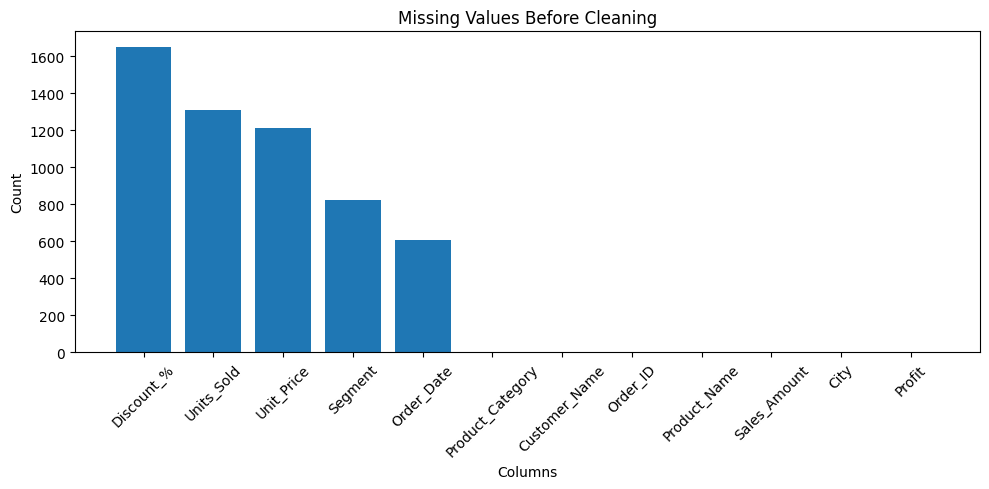

In [10]:
missing_counts = df.isna().sum().sort_values(ascending=False)

plt.figure()
plt.bar(missing_counts.index, missing_counts.values)
plt.title("Missing Values Before Cleaning")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Why this visualization was chosen:**  
This chart was chosen to clearly show which columns had the most missing data before cleaning.

**Insight:**  
It shows that columns such as `Units_Sold`, `Unit_Price`, `Discount_%`, `Order_Date`, and `Segment` had significant missing values.

**What can be learned:**  
The dataset required cleaning before meaningful analysis could be performed.


## Plot 2 - Records by product category

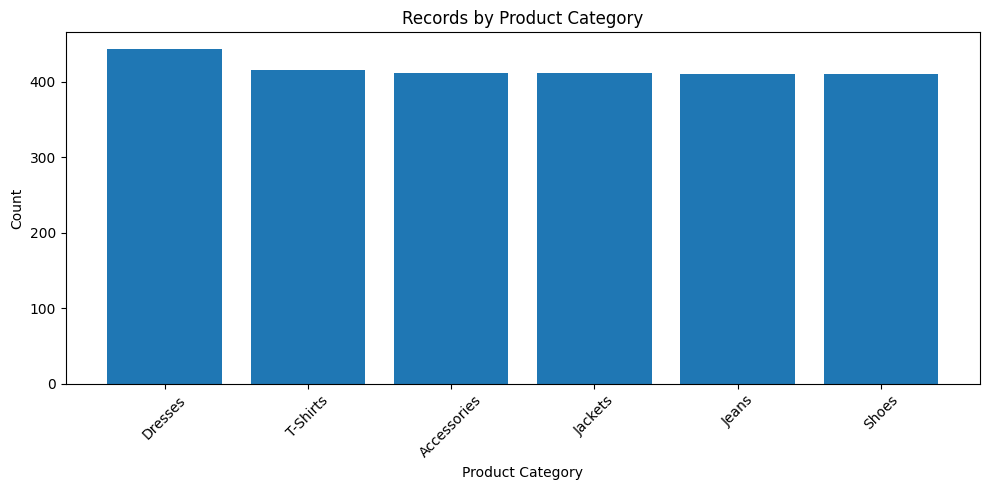

In [11]:
category_counts = cleaned["Product_Category"].value_counts()

plt.figure()
plt.bar(category_counts.index, category_counts.values)
plt.title("Records by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Why this visualization was chosen:**  
This chart compares the number of records in each product category.

**Insight:**  
The distribution of records across categories is relatively balanced, with small differences between categories.

**What can be learned:**  
The dataset covers multiple categories and allows fair category-level comparison.


## Plot 3 - Records by city

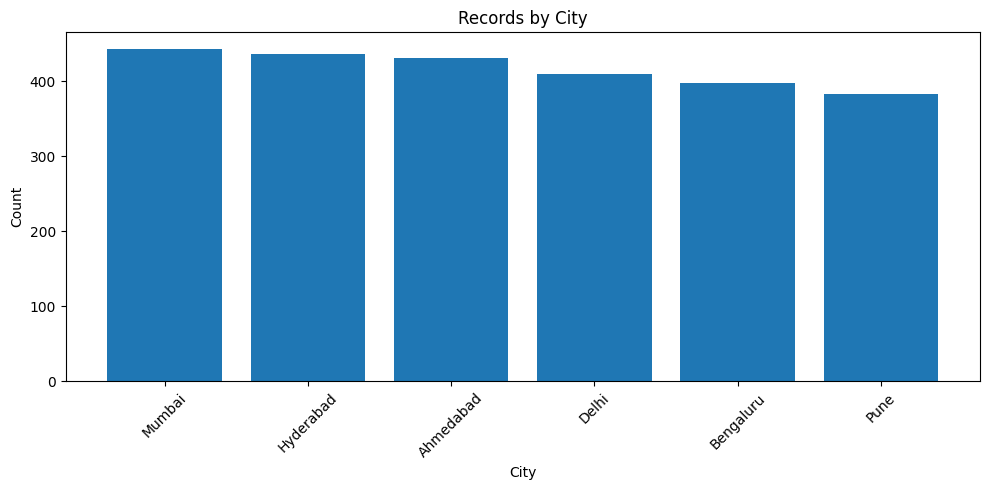

In [12]:
city_counts = cleaned["City"].value_counts()

plt.figure()
plt.bar(city_counts.index, city_counts.values)
plt.title("Records by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Why this visualization was chosen:**  
This chart compares the number of records across cities.

**Insight:**  
Some cities such as Mumbai and Ahmedabad appear more frequently than others.

**What can be learned:**  
The dataset is not evenly distributed across cities, which may affect comparisons if not interpreted carefully.


## Plot 4 - Records by segment

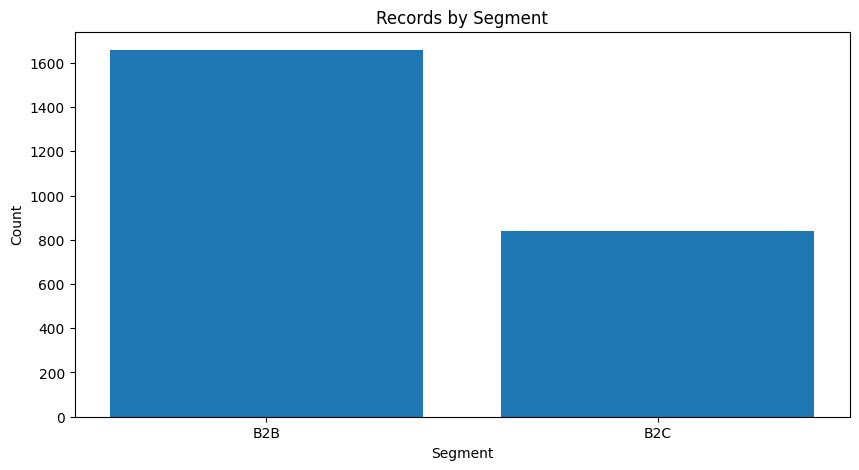

In [13]:
segment_counts = cleaned["Segment"].value_counts()

plt.figure()
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Records by Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

**Why this visualization was chosen:**  
This chart compares the number of records in customer segments.

**Insight:**  
The data is split between `B2B` and `B2C`, with no missing segment values after cleaning.

**What can be learned:**  
Segment-based analysis is possible after cleaning and standardization.


## Plot 5 - Total sales by product category

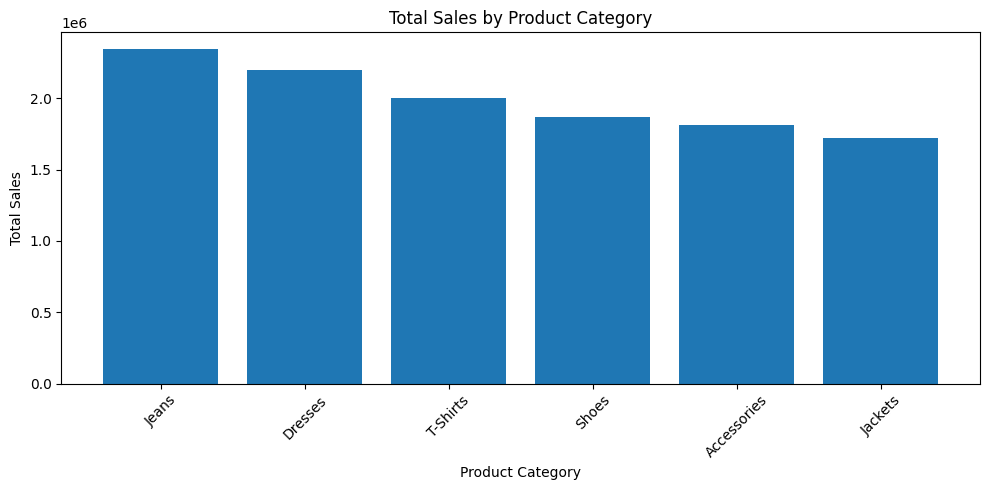

Product_Category
Jeans          2345154.68
Dresses        2195064.26
T-Shirts       2003734.18
Shoes          1869195.20
Accessories    1812250.10
Jackets        1723032.35
Name: Sales_Amount, dtype: float64

In [14]:
sales_by_category = cleaned.groupby("Product_Category")["Sales_Amount"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(sales_by_category.index, sales_by_category.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sales_by_category

**Why this visualization was chosen:**  
This chart compares total sales across product categories.

**Insight:**  
Some categories generate higher total sales than others, which may reflect stronger demand or higher prices.

**What can be learned:**  
The business can identify the strongest-performing categories and investigate weaker ones.


## Plot 6 - Total sales by city

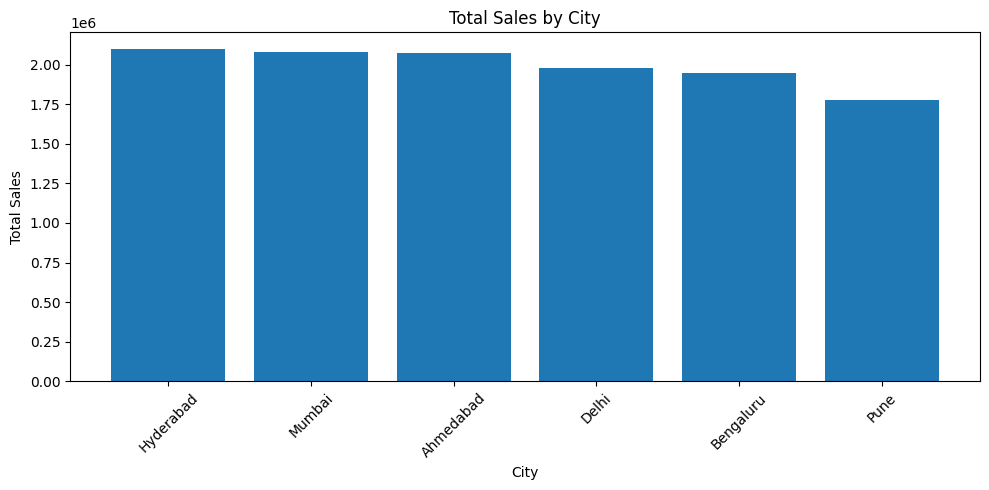

City
Hyderabad    2098386.60
Mumbai       2076257.44
Ahmedabad    2070116.90
Delhi        1980965.52
Bengaluru    1947938.18
Pune         1774766.13
Name: Sales_Amount, dtype: float64

In [15]:
sales_by_city = cleaned.groupby("City")["Sales_Amount"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(sales_by_city.index, sales_by_city.values)
plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sales_by_city

**Why this visualization was chosen:**  
This chart compares city-level sales performance.

**Insight:**  
Some cities contribute more to total sales than others.

**What can be learned:**  
City-level differences may help identify stronger markets and areas with lower performance.


## Plot 7 - Monthly sales trend

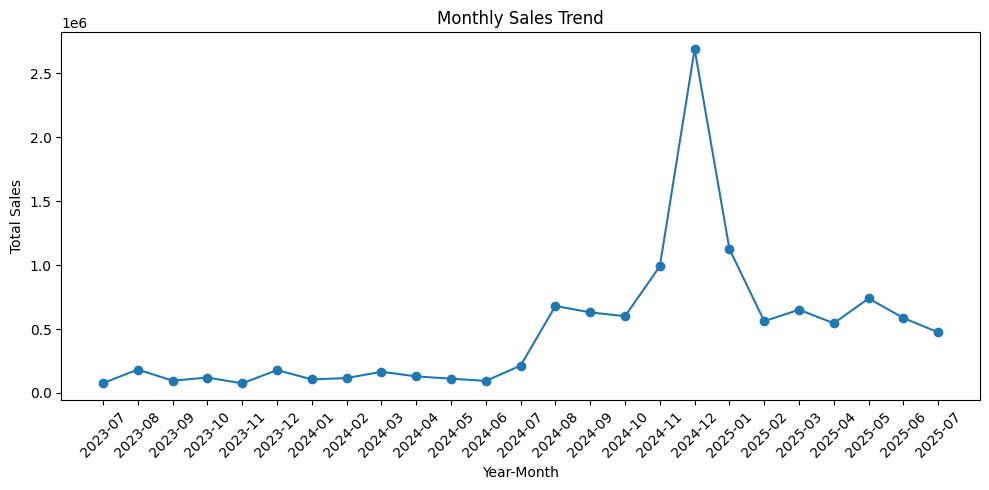

,Order_Year,Order_Month,Sales_Amount,Year-Month
0,2023,7,77236.37,2023-07
1,2023,8,183052.09,2023-08
2,2023,9,96277.59,2023-09
3,2023,10,120626.81,2023-10
4,2023,11,75191.57,2023-11
5,2023,12,179019.09,2023-12
6,2024,1,106294.49,2024-01
7,2024,2,116353.02,2024-02
8,2024,3,165996.58,2024-03
9,2024,4,129729.98,2024-04


In [16]:
monthly_sales = cleaned.groupby(["Order_Year", "Order_Month"])["Sales_Amount"].sum().reset_index()
monthly_sales["Year-Month"] = monthly_sales["Order_Year"].astype(str) + "-" + monthly_sales["Order_Month"].astype(str).str.zfill(2)

plt.figure()
plt.plot(monthly_sales["Year-Month"], monthly_sales["Sales_Amount"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_sales

**Why this visualization was chosen:**  
A line chart is suitable for showing trends over time.

**Insight:**  
The sales values change across months, which helps reveal fluctuations in performance over time.

**What can be learned:**  
Time-based analysis can help identify stronger and weaker sales periods.


## Plot 8 - Unit price distribution

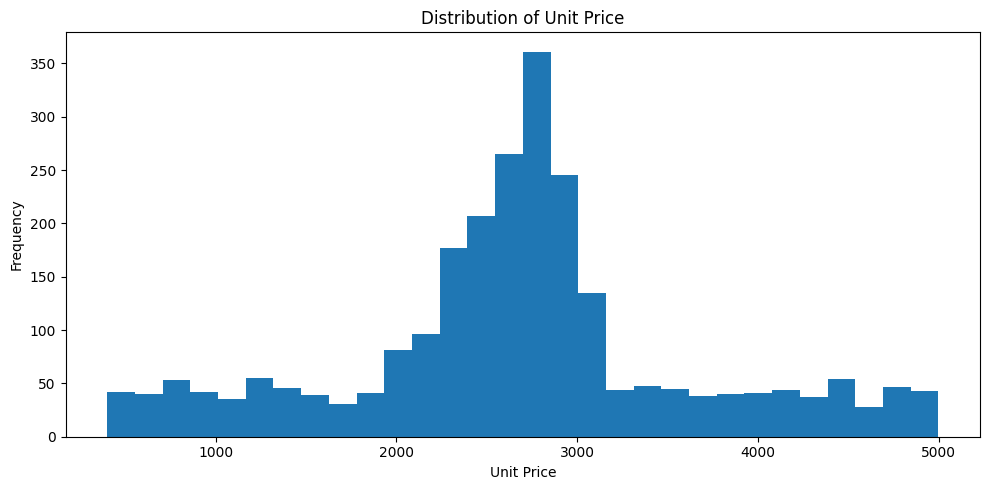

In [17]:
plt.figure()
plt.hist(cleaned["Unit_Price"], bins=30)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Why this visualization was chosen:**  
A histogram is useful for understanding the distribution of numeric values.

**Insight:**  
It shows how unit prices are spread across the dataset and whether prices cluster in certain ranges.

**What can be learned:**  
This helps understand pricing patterns and whether the data contains concentration in specific price intervals.


## 8. Final conclusion

### Main conclusions
- The dataset contained multiple data quality problems that required cleaning before analysis.
- After cleaning, the dataset became more consistent and suitable for EDA.
- The visualizations revealed patterns across categories, cities, customer segments, and time.
- Category-level and city-level comparisons became clearer after recalculating and standardizing the key fields.

### What was learned from the results?
This analysis shows how data cleaning improves reliability and helps reveal useful business patterns.  
Without cleaning, the analysis would have been misleading because of missing values, incorrect formats, and inconsistent entries.
